In [37]:
!pip install -q datasets transformers

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from transformers import CLIPTokenizerFast
from torchvision import transforms
import random
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import init
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [40]:
flickr8k = load_dataset("jxie/flickr8k")

train_samples = flickr8k["train"]
val_samples = flickr8k["validation"]

In [41]:
print("Train samples:", len(train_samples))
print("Validation samples:", len(val_samples))
print("\nColumn names:", train_samples.column_names)

Train samples: 6000
Validation samples: 1000

Column names: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']


In [42]:
train_samples[:1]


{'image': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x399>],
 'caption_0': ['A black dog is running after a white dog in the snow .'],
 'caption_1': ['Black dog chasing brown dog through snow'],
 'caption_2': ['Two dogs chase each other across the snowy ground .'],
 'caption_3': ['Two dogs play together in the snow .'],
 'caption_4': ['Two dogs running through a low lying body of water .']}

In [43]:
@dataclass
class VisionConfig:
  # image
  image_size: int = 224
  patch_size: int = 16
  image_channels: int = 3

  # vision transformer
  embedding_size: int = 256
  n_layers: int = 4
  n_heads: int = 4
  mlp_ratio: float = 4.0 # [hidden size of the MLP block]
  dropout: float = 0.1

@dataclass
class TextConfig:
  # tokenizer
  vocab_size: int = 49_408
  block_size: int = 32

  # text transformer
  embedding_size: int = 256
  n_layers: int = 4
  n_heads: int = 4
  mlp_ratio: float = 4.0
  dropout: float = 0.1

@dataclass
class CLIPConfig:
  vision: VisionConfig = field(default_factory=VisionConfig)
  text: TextConfig = field(default_factory=TextConfig)

  projection_dim: int = 256 # [shared embedding space]
  temperature: float = 0.07 # [initial temperature for the learnable logit scale]

In [44]:
class PatchEmbedding(nn.Module):
  def __init__(self, config: VisionConfig):
    super().__init__()
    # [convert an image into a sequence of vectors, where each vector represents one image patch]
    assert config.image_size % config.patch_size == 0, (
    f"image_size ({config.image_size}) must be divisible by "
    f"patch_size ({config.patch_size})"
    )

    self.num_patches = (config.image_size // config.patch_size) ** 2 # (224 * 224) // (16 * 16) = 196 patches
    self.projection = nn.Conv2d(
        in_channels = config.image_channels,
        out_channels = config.embedding_size,
        kernel_size = config.patch_size,
        stride = config.patch_size
    )

  def forward(self, images):
    # images (B, C, H, W)
    patches = self.projection(images) # (B, embedding_size, H/patch_size, W/patch_size)
    patches = patches.flatten(2) # (B, embedding_size, num_patches)
    patches = patches.transpose(1, 2) # (B, num_patches, embedding_size)
    return patches

In [45]:
class TransformerBlock(nn.Module):
  def __init__(self, config): # [config: VisionConfig or TextConfig]
    super().__init__()
    self.layer_norm_1 = nn.LayerNorm(config.embedding_size)
    self.mha = nn.MultiheadAttention(embed_dim=config.embedding_size, num_heads=config.n_heads, dropout=config.dropout, batch_first=True)
    self.layer_norm_2 = nn.LayerNorm(config.embedding_size)
    hidden_size = int(config.embedding_size * config.mlp_ratio)
    self.mlp = nn.Sequential(
        nn.Linear(config.embedding_size, hidden_size),
        nn.Dropout(config.dropout),
        nn.GELU(),
        nn.Linear(hidden_size, config.embedding_size),
        nn.Dropout(config.dropout)
    )

  def forward(self, x, attention_mask=None):
    # x: (B, T, C)
    normalized_x = self.layer_norm_1(x) # (B, T, C)
    attn_output, _ = self.mha(normalized_x, normalized_x, normalized_x, attn_mask=attention_mask, need_weights=False) # (B, T, C)
    x = x + attn_output # (B, T, C)
    x = x + self.mlp(self.layer_norm_2(x)) # (B, T, C)
    return x

In [46]:
class VisionEncoder(nn.Module):
  def __init__(self, config: VisionConfig):
    super().__init__()
    self.patch_embedding = PatchEmbedding(config)
    num_patches = self.patch_embedding.num_patches

    # [learnable [CLS]-style token that will be prepended to the patch sequence]
    self.class_token = nn.Parameter(torch.randn(1, 1, config.embedding_size) * 0.02) # (1 shared batch, 1 cls token, embedding_size)

    # [learnable position embedding: patch tokens + 1 class token]
    self.position_embedding = nn.Parameter(torch.randn(1, num_patches+1, config.embedding_size) * 0.02)

    self.dropout = nn.Dropout(config.dropout)
    self.transformer_blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
    self.layer_norm = nn.LayerNorm(config.embedding_size)

  def forward(self, images):
    # images: (B, C, H, W)
    x = self.patch_embedding(images) # (B, num_patches, embedding_size)
    batch_size = x.shape[0]

    class_token = self.class_token.expand(batch_size, -1, -1) # (1, 1, embedding_size) -> (B, 1, embedding_size)
    x = torch.cat([class_token, x], dim=1) # (B, num_patches + 1, embedding_size)

    x = x + self.position_embedding # (B, num_patches + 1, embedding_size)
    x = self.dropout(x)

    for block in self.transformer_blocks:
      x = block(x) # (B, num_patches + 1, embedding_size)
    x = self.layer_norm(x) # (B, num_patches + 1, embedding_size)

    # [take the class token as the image representation]
    image_features = x[:, 0] # (B, embedding_size)
    return image_features

In [47]:
class TextEncoder(nn.Module):
  def __init__(self, config: TextConfig):
    super().__init__()
    self.block_size = config.block_size
    self.token_embedding = nn.Embedding(config.vocab_size, config.embedding_size) # (V, C)
    self.position_embedding = nn.Parameter(torch.randn(1, self.block_size, config.embedding_size) * 0.02) # [trainable] (B, T, C)
    self.transformer_blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
    self.layer_norm = nn.LayerNorm(config.embedding_size)

    # [causal mask so each token can only attend to itself and earlier tokens]
    causal_mask = torch.full((self.block_size, self.block_size), float("-inf")) # (T, T)
    causal_mask = torch.triu(causal_mask, diagonal=1) # (T, T)
    self.register_buffer("causal_mask", causal_mask, persistent=False)

  def forward(self, token_ids, eos_positions):
    # token_ids: (B, <=T)
    # eos_positions: (B,) [index of the end-of-text token in each sequence]

    seq_len = token_ids.shape[1] #(<=T,)

    if seq_len > self.block_size:
      raise ValueError(
          f"Sequence length {seq_len} exceeds "
          f"context length {self.block_size}"
      )

    x = self.token_embedding(token_ids) # (B, <=T, C)
    x = x + self.position_embedding[:, :seq_len] # (B, <=T, C)

    mask = self.causal_mask[:seq_len, :seq_len] # (<=T, <=T)

    for block in self.transformer_blocks:
      x = block(x, attention_mask=mask) # (B, <=T, C)

    x = self.layer_norm(x) # (B, <=T, C)
    batch_indices = torch.arange(x.shape[0], device=x.device) # (B,)

    # [the EOS token can attend to every earlier token, so its final vector can
    # serve as a representation of the entire sentence.]
    text_features = x[batch_indices, eos_positions] # (B, C)
    return text_features

In [48]:
class CLIP(nn.Module):
  def __init__(self, config: CLIPConfig):
    super().__init__()

    self.image_encoder = VisionEncoder(config.vision)
    self.text_encoder = TextEncoder(config.text)

    # [project both modalities into a shared embedding space]
    self.image_projection = nn.Linear(config.vision.embedding_size, config.projection_dim, bias=False)
    self.text_projection = nn.Linear(config.text.embedding_size, config.projection_dim, bias=False)

    # [learnable temperature]
    self.logit_scale = nn.Parameter(torch.log(torch.tensor(1.0 / config.temperature)))

  def encode_image(self, images):
    # images: (B, C, H, W)
    image_features = self.image_encoder(images) # (B, vision.embedding_size)
    image_embeddings = self.image_projection(image_features) # (B, projection_dim)
    image_embeddings = F.normalize(image_embeddings, p=2, dim=-1) # (B, projection_dim) [L2-normalized]
    return image_embeddings

  def encode_text(self, token_ids, eos_positions):
    # token_ids: (B, T), eos_positions: (B,)
    text_features = self.text_encoder(token_ids, eos_positions) # (B, text.embedding_size)
    text_embeddings = self.text_projection(text_features) # (B, projection_dim)
    text_embeddings = F.normalize(text_embeddings, p=2, dim=-1) # (B, projection_dim) [L2-normalized]
    return text_embeddings

  def forward(self, images, token_ids, eos_positions):
    image_embeddings = self.encode_image(images) # (B, projection_dim)
    text_embeddings = self.encode_text(token_ids, eos_positions) # (B, projection_dim)

    # [convert back to the actual scale]
    scale = torch.exp(self.logit_scale).clamp(max=100)

    # cosine similarity
    logits_per_image = (scale * image_embeddings) @ text_embeddings.T # (B, projection_dim) @ (projection_dim, B) => (B, B)
    logits_per_text = logits_per_image.T # (B, B)
    return logits_per_image, logits_per_text

In [49]:
config = CLIPConfig()
model = CLIP(config).to(device)
print(sum(p.numel() for p in model.parameters())/1e6, "M parameters")

19.354369 M parameters


In [50]:
def kaiming_init_weights(m):
  if isinstance(m, (nn.Linear)):
    init.kaiming_normal_(m.weight)

model.apply(kaiming_init_weights)

CLIP(
  (image_encoder): VisionEncoder(
    (patch_embedding): PatchEmbedding(
      (projection): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (transformer_blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (layer_norm_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
          (2): GELU(approximate='none')
          (3): Linear(in_features=1024, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (text_encoder): TextEncod

In [51]:
# [The model should make the diagonal similarity values large:
# CLIP calculates loss in both directions:
#   image-to-text: given an image, retrieve its caption
#   text-to-image: given a caption, retrieve its image]

def clip_loss(logits_per_image, logits_per_text):
    batch_size = logits_per_image.shape[0]

    targets = torch.arange(batch_size, device=logits_per_image.device) # (B,) [diagonal]
    image_to_text_loss = F.cross_entropy(logits_per_image, targets)
    text_to_image_loss = F.cross_entropy(logits_per_text, targets)

    return (image_to_text_loss + text_to_image_loss) / 2

In [52]:
tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

In [53]:
print("Vocabulary size:", tokenizer.vocab_size)
print("EOS token:", tokenizer.eos_token)
print("EOS token ID:", tokenizer.eos_token_id)
print("PAD token ID:", tokenizer.pad_token_id)

Vocabulary size: 49408
EOS token: <|endoftext|>
EOS token ID: 49407
PAD token ID: 49407


In [54]:
image_size = config.vision.image_size

clip_mean = (0.48145466, 0.4578275, 0.40821073)
clip_std = (0.26862954, 0.26130258, 0.27577711)

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std),
])

val_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std),
])

In [55]:
class CLIPDataset(Dataset):
    def __init__(self, samples, tokenizer, transform, max_length=32, random_caption=True):
        self.samples = samples
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length
        self.random_caption = random_caption

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        item = self.samples[index]

        image = item["image"].convert("RGB")
        image = self.transform(image)

        captions = [
            item["caption_0"],
            item["caption_1"],
            item["caption_2"],
            item["caption_3"],
            item["caption_4"],
        ]

        caption = (
            random.choice(captions)
            if self.random_caption
            else captions[0]
        )

        tokens = self.tokenizer(caption, max_length=self.max_length, padding="max_length", truncation=True, return_tensors="pt")
        token_ids = tokens["input_ids"].squeeze(0)

        eos_positions = (token_ids == self.tokenizer.eos_token_id).nonzero(as_tuple=True)[0]
        eos_position = eos_positions[0]

        return {
            "image": image,
            "token_ids": token_ids,
            "eos_position": eos_position,
            "caption": caption,
        }

In [56]:
tokenizer = CLIPTokenizerFast.from_pretrained(
    "openai/clip-vit-base-patch32"
)

train_dataset = CLIPDataset(
    samples=train_samples,
    tokenizer=tokenizer,
    transform=train_transform,
    max_length=config.text.block_size,
    random_caption=True
)

val_dataset = CLIPDataset(
    samples=val_samples,
    tokenizer=tokenizer,
    transform=val_transform,
    max_length=config.text.block_size,
    random_caption=False
)

In [57]:
# training parameters

batch_size = 8
sequence_length = 32
epochs = 10

In [58]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [59]:
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

In [60]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(epochs):
    # ---------------- Train ----------------
    model.train()

    train_loss = 0
    train_acc = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        token_ids = batch["token_ids"].to(device)
        eos_positions = batch["eos_position"].to(device)

        logits_per_image, logits_per_text = model(images, token_ids, eos_positions)
        loss = clip_loss(logits_per_image, logits_per_text)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        targets = torch.arange(images.size(0), device=device)

        image_predictions = logits_per_image.argmax(dim=1)
        text_predictions = logits_per_text.argmax(dim=1)

        image_acc = torch.mean((image_predictions == targets).float())
        text_acc = torch.mean((text_predictions == targets).float())
        train_acc += ((image_acc + text_acc) / 2).item()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    # ---------------- Validation ----------------
    model.eval()

    val_loss = 0
    val_acc = 0

    with torch.inference_mode():
        for batch in val_loader:
            images = batch["image"].to(device)
            token_ids = batch["token_ids"].to(device)
            eos_positions = batch["eos_position"].to(device)

            logits_per_image, logits_per_text = model(images, token_ids, eos_positions)

            loss = clip_loss(logits_per_image, logits_per_text)
            val_loss += loss.item()

            targets = torch.arange(images.size(0), device=device)

            image_predictions = logits_per_image.argmax(dim=1)
            text_predictions = logits_per_text.argmax(dim=1)

            image_acc = torch.mean((image_predictions == targets).float())
            text_acc = torch.mean((text_predictions == targets).float())
            val_acc += ((image_acc + text_acc) / 2).item()

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 2.0161 | Val Loss: 1.9245 | Train Acc: 0.1830 | Val Acc: 0.2355
Epoch 2/10 | Train Loss: 1.9093 | Val Loss: 1.8834 | Train Acc: 0.2407 | Val Acc: 0.2520
Epoch 3/10 | Train Loss: 1.8373 | Val Loss: 1.8706 | Train Acc: 0.2826 | Val Acc: 0.2670
Epoch 4/10 | Train Loss: 1.7912 | Val Loss: 1.7909 | Train Acc: 0.3028 | Val Acc: 0.3030
Epoch 5/10 | Train Loss: 1.7484 | Val Loss: 1.7723 | Train Acc: 0.3126 | Val Acc: 0.3005
Epoch 6/10 | Train Loss: 1.6968 | Val Loss: 1.7990 | Train Acc: 0.3356 | Val Acc: 0.3185
Epoch 7/10 | Train Loss: 1.6596 | Val Loss: 1.7486 | Train Acc: 0.3577 | Val Acc: 0.3305
Epoch 8/10 | Train Loss: 1.6385 | Val Loss: 1.6958 | Train Acc: 0.3658 | Val Acc: 0.3625
Epoch 9/10 | Train Loss: 1.6173 | Val Loss: 1.7268 | Train Acc: 0.3743 | Val Acc: 0.3290
Epoch 10/10 | Train Loss: 1.5850 | Val Loss: 1.6788 | Train Acc: 0.3811 | Val Acc: 0.3425


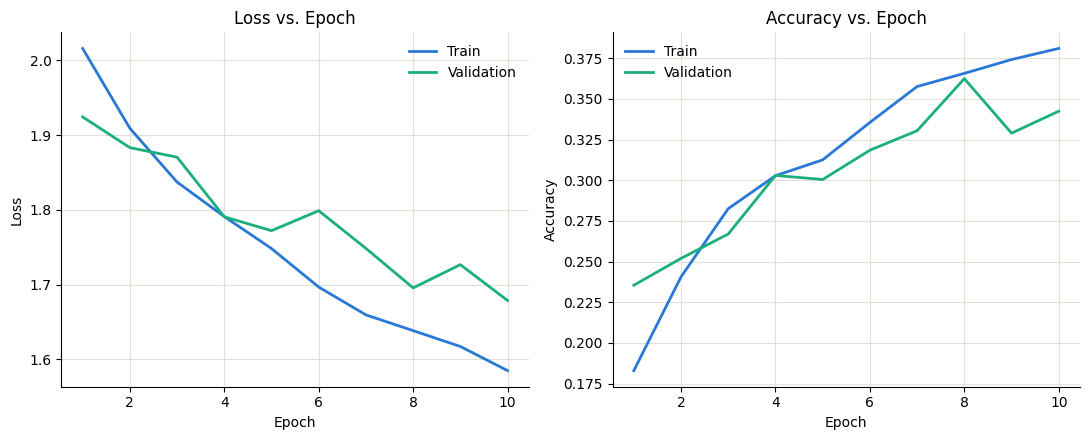

In [62]:
epochs_axis = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

panels = [
    ("train_loss", "val_loss", "Loss"),
    ("train_acc", "val_acc", "Accuracy"),
]

for ax, (train_key, val_key, title) in zip(axes, panels):
    ax.plot(epochs_axis, history[train_key], linewidth=2, color="#2a78d6", label="Train")
    ax.plot(epochs_axis, history[val_key], linewidth=2, color="#1baf7a", label="Validation")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs. Epoch")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()